# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Company Bankruptcy Prediction](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction) (data kebangkrutan perusahaan Taiwan, 6819 sampel, 95 fitur finansial, target `Bankrupt?` biner).

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [21]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
print("Path to dataset files:", path)

Path to dataset files: /home/irzam/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2


In [22]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv(path + "/data.csv")
df.columns = [c.strip() for c in df.columns]  # nama kolom asli berawalan spasi

print("Shape:", df.shape)
display(df.head())
df.info()
print("\nJumlah missing value per kolom (total):", int(df.isna().sum().sum()))
df.describe().T.head(10)

Shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
Operating Profit Rate,6819.0,0.998755,0.013010,0.0,0.998969,0.999022,0.999095,1.0
Pre-tax net Interest Rate,6819.0,0.797190,0.012869,0.0,0.797386,0.797464,0.797579,1.0
After-tax net Interest Rate,6819.0,0.809084,0.013601,0.0,0.809312,0.809375,0.809469,1.0
Non-industry income and expenditure/revenue,6819.0,0.303623,0.011163,0.0,0.303466,0.303525,0.303585,1.0


Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


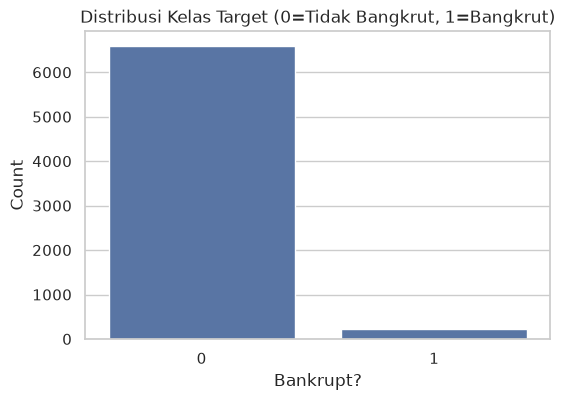

In [23]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df["Bankrupt?"].value_counts())
print(df["Bankrupt?"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Bankrupt?")
plt.title("Distribusi Kelas Target (0=Tidak Bangkrut, 1=Bangkrut)")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.show()

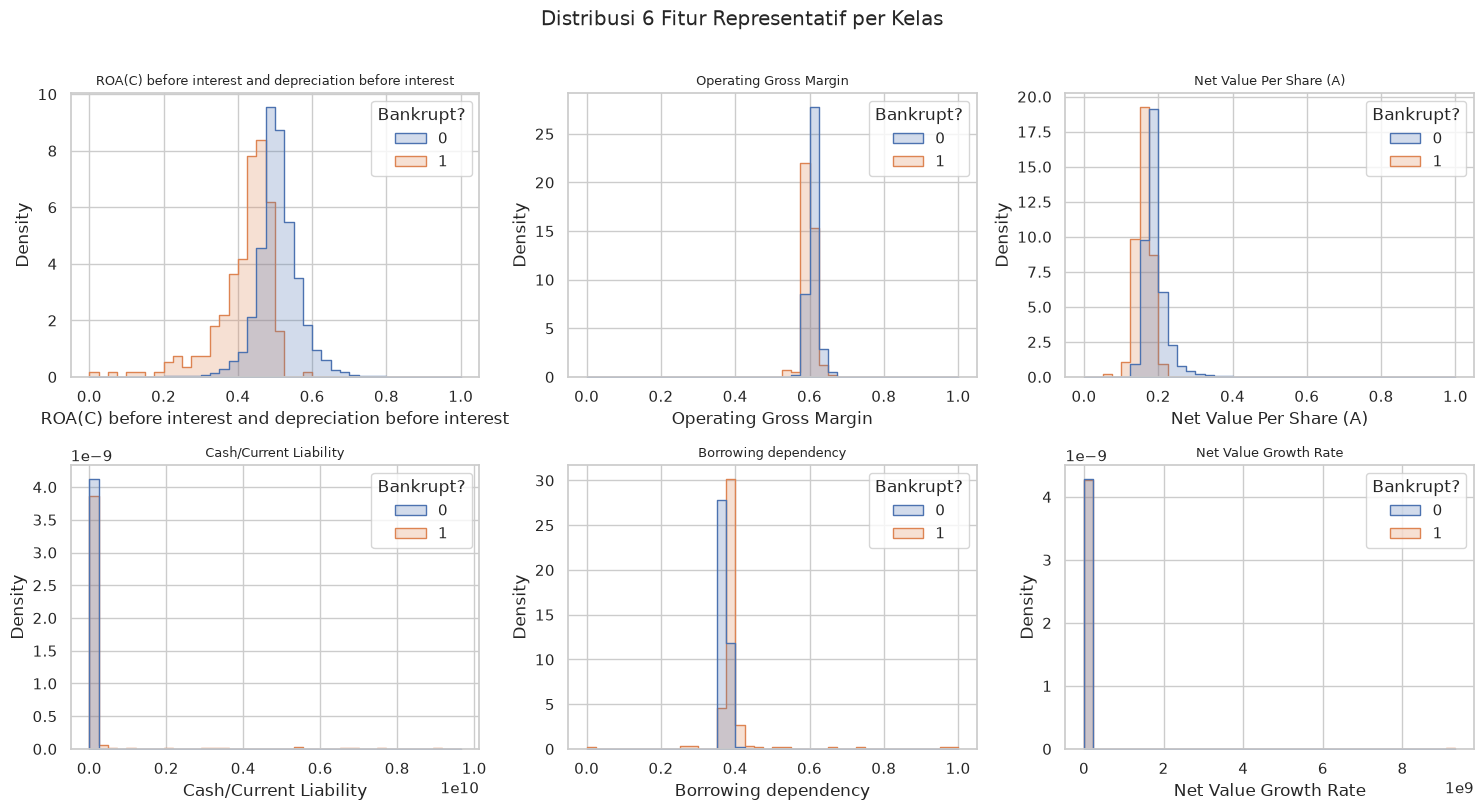

In [24]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
# Karena ada 95 fitur, pairplot seluruh fitur tidak feasible -> gunakan 6 fitur representatif.
rep_features = ["ROA(C) before interest and depreciation before interest",
                "Operating Gross Margin",
                "Net Value Per Share (A)",
                "Cash/Current Liability",
                "Borrowing dependency",
                "Net Value Growth Rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), rep_features):
    sns.histplot(data=df, x=feat, hue="Bankrupt?", bins=40, element="step",
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(feat, fontsize=9)
plt.suptitle("Distribusi 6 Fitur Representatif per Kelas", y=1.01)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Net Income to Total Assets                                -0.3155
ROA(A) before interest and % after tax                    -0.2829
ROA(B) before interest and depreciation after tax         -0.2731
ROA(C) before interest and depreciation before interest   -0.2608
Net worth/Assets                                          -0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                   -0.2196
Retained Earnings to Total Assets                         -0.2178
Net profit before tax/Paid-in capital                     -0.2079
Per Share Net profit before tax (Yuan ¥)                  -0.2014
Current Liability to Assets                                0.1945
Working Capital to Total Assets                           -0.1931
Net Income to Stockholder's Equity                        -0.1810
Borrowing dependency                                       0.1765
Current Liability to Current Assets                        0.1713
Name: Bank

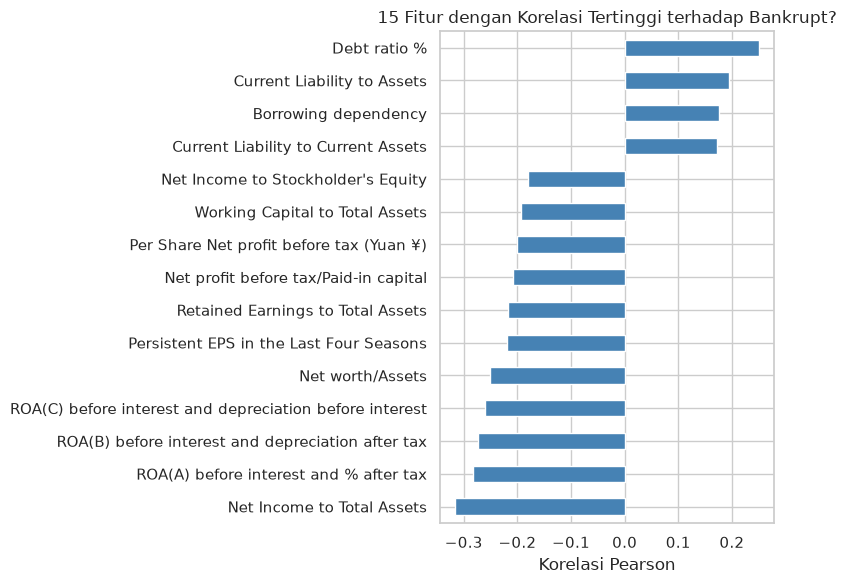

In [25]:
# EDA tambahan 1: korelasi tiap fitur terhadap target -> 15 fitur paling berkorelasi.
corr_target = df.corr(numeric_only=True)["Bankrupt?"].drop("Bankrupt?").sort_values(key=abs, ascending=False)
print(corr_target.head(15).round(4))

plt.figure(figsize=(8, 6))
corr_target.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("15 Fitur dengan Korelasi Tertinggi terhadap Bankrupt?")
plt.xlabel("Korelasi Pearson")
plt.tight_layout()
plt.show()

In [26]:
# EDA tambahan 2: perbandingan rata-rata fitur antar kelas + cek duplikat.
print("Jumlah baris duplikat:", int(df.duplicated().sum()))
compare = df.groupby("Bankrupt?")[corr_target.head(8).index.tolist()].mean().T
compare.columns = ["Tidak Bangkrut (0)", "Bangkrut (1)"]
compare.round(4)

Jumlah baris duplikat: 0


,Tidak Bangkrut (0),Bangkrut (1)
Net Income to Total Assets,0.8101,0.7381
ROA(A) before interest and % after tax,0.5620,0.4569
ROA(B) before interest and depreciation after tax,0.5567,0.4615
ROA(C) before interest and depreciation before interest,0.5081,0.4185
Net worth/Assets,0.8893,0.8130
Debt ratio %,0.1107,0.1870
Persistent EPS in the Last Four Seasons,0.2301,0.1888
Retained Earnings to Total Assets,0.9357,0.9042


# 2. Preprocessing

In [27]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value per kolom (5 teratas):")
print(df.isna().sum().sort_values(ascending=False).head())
print("\nTotal missing:", int(df.isna().sum().sum()))
print("Duplikat:", int(df.duplicated().sum()))
# Hasil: tidak ada missing value dan tidak ada duplikat, sehingga tidak ada imputasi/drop yang diperlukan.
# (Jika ada, imputasi median harus di-fit hanya pada train set agar tidak terjadi leakage.)

Missing value per kolom (5 teratas):
Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
dtype: int64

Total missing: 0
Duplikat: 0


In [28]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
print(df.dtypes.value_counts())
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("Kolom non-numerik:", obj_cols)
# Hasil: seluruh 96 kolom bertipe numerik (float64/int64), tidak ada fitur kategorikal -> tidak perlu encoding.
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Kolom konstan (hanya 1 nilai unik):", const_cols)
# 'Net Income Flag' bernilai sama untuk semua baris -> tidak informatif. Decision Tree tidak akan pernah
# memakainya sebagai split, jadi kolom ini dibiarkan (tidak berpengaruh ke model).

float64    93
int64       3
Name: count, dtype: int64
Kolom non-numerik: []
Kolom konstan (hanya 1 nilai unik): ['Net Income Flag']


In [29]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nProporsi kelas train:\n", y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas test:\n", y_test.value_counts(normalize=True).round(4))

X_train: (5455, 95)  X_test: (1364, 95)

Proporsi kelas train:
 Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64

Proporsi kelas test:
 Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [30]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)
print("Kedalaman pohon (gini):  ", dt_gini.get_depth(), "| Jumlah daun:", dt_gini.get_n_leaves())
print("Akurasi train (gini):", round(dt_gini.score(X_train, y_train), 4))

Kedalaman pohon (gini):   20 | Jumlah daun: 124
Akurasi train (gini): 1.0


In [31]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)
print("Akurasi test (gini):", round(accuracy_score(y_test, y_pred_gini), 4))

Akurasi test (gini): 0.9611


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [32]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)
print("Kedalaman pohon (entropy):", dt_entropy.get_depth(), "| Jumlah daun:", dt_entropy.get_n_leaves())
print("Akurasi train (entropy):", round(dt_entropy.score(X_train, y_train), 4))

Kedalaman pohon (entropy): 17 | Jumlah daun: 99
Akurasi train (entropy): 1.0


In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)
print("Akurasi test (entropy):", round(accuracy_score(y_test, y_pred_entropy), 4))

Akurasi test (entropy): 0.9641


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [34]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# -> Selisih Gini vs Entropy sangat kecil (~4 sampel test), Entropy dipakai sebagai tie-break (F1 & precision sedikit lebih tinggi).
# Selain accuracy, dicatat juga precision/recall/F1 kelas bangkrut, karena accuracy menipu pada data imbalanced.
depths = [1, 2, 3, 5, 10, 15, None]
train_acc, test_acc, test_prec, test_rec, test_f1, n_leaves = [], [], [], [], [], []
depth_models = {}
for d in depths:
    m = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    depth_models[d] = m
    n_leaves.append(m.get_n_leaves())
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(accuracy_score(y_test, pred))
    test_prec.append(precision_score(y_test, pred, zero_division=0))
    test_rec.append(recall_score(y_test, pred, zero_division=0))
    test_f1.append(f1_score(y_test, pred, zero_division=0))
    print(f"max_depth={d}: train={train_acc[-1]:.4f}, test={test_acc[-1]:.4f}, "
          f"pred_bangkrut={pred.sum()}, recall={test_rec[-1]:.4f}, F1={test_f1[-1]:.4f}")

max_depth=1: train=0.9677, test=0.9677, pred_bangkrut=0, recall=0.0000, F1=0.0000
max_depth=2: train=0.9677, test=0.9677, pred_bangkrut=0, recall=0.0000, F1=0.0000
max_depth=3: train=0.9683, test=0.9699, pred_bangkrut=9, recall=0.1364, F1=0.2264
max_depth=5: train=0.9743, test=0.9663, pred_bangkrut=38, recall=0.4091, F1=0.4390
max_depth=10: train=0.9930, test=0.9633, pred_bangkrut=38, recall=0.3636, F1=0.3902
max_depth=15: train=0.9993, test=0.9626, pred_bangkrut=41, recall=0.3864, F1=0.4000
max_depth=None: train=1.0000, test=0.9641, pred_bangkrut=39, recall=0.3864, F1=0.4096


In [35]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
depth_results = pd.DataFrame({
    "max_depth": [str(d) for d in depths],
    "n_leaves": n_leaves,
    "train_acc": train_acc,
    "test_acc": test_acc,
    "precision_bangkrut": test_prec,
    "recall_bangkrut": test_rec,
    "f1_bangkrut": test_f1,
})
depth_results.round(4)

,max_depth,n_leaves,train_acc,test_acc,precision_bangkrut,recall_bangkrut,f1_bangkrut
0,1,2,0.9677,0.9677,0.0000,0.0000,0.0000
1,2,4,0.9677,0.9677,0.0000,0.0000,0.0000
2,3,8,0.9683,0.9699,0.6667,0.1364,0.2264
3,5,25,0.9743,0.9663,0.4737,0.4091,0.4390
4,10,82,0.9930,0.9633,0.4211,0.3636,0.3902
5,15,97,0.9993,0.9626,0.4146,0.3864,0.4000
6,None,99,1.0000,0.9641,0.4359,0.3864,0.4096


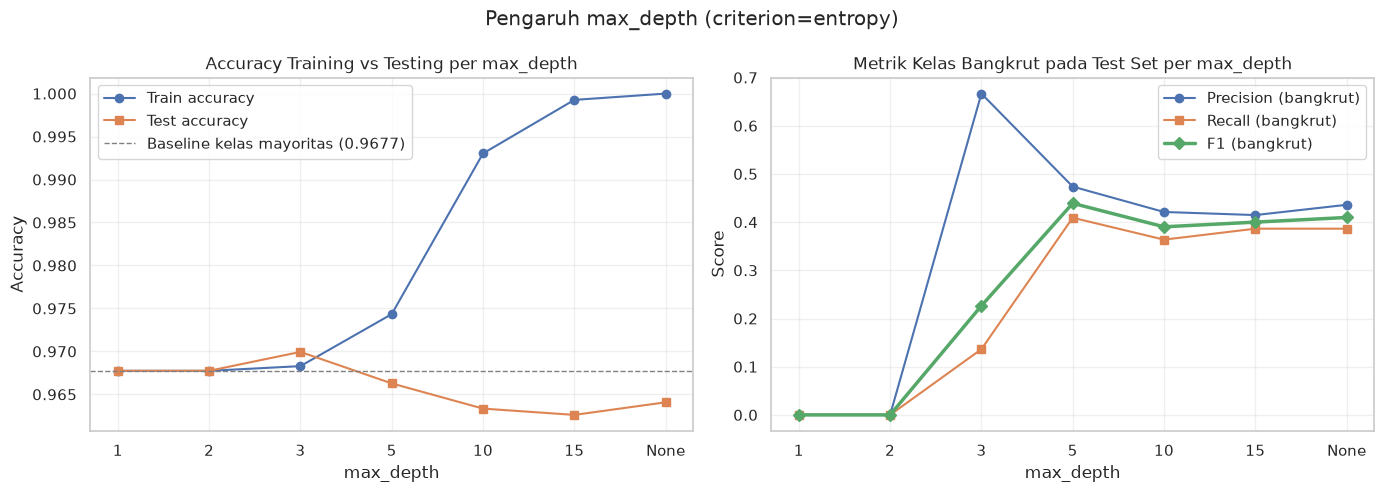

In [36]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
# Panel kanan: metrik kelas bangkrut, karena accuracy saja bisa menyesatkan pada data imbalanced.
x = np.arange(len(depths))
labels = [str(d) for d in depths]
majority_baseline = (y_test == 0).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x, train_acc, marker="o", label="Train accuracy")
axes[0].plot(x, test_acc, marker="s", label="Test accuracy")
axes[0].axhline(majority_baseline, color="gray", ls="--", lw=1,
                label=f"Baseline kelas mayoritas ({majority_baseline:.4f})")
axes[0].set_title("Accuracy Training vs Testing per max_depth")
axes[0].set_ylabel("Accuracy")

axes[1].plot(x, test_prec, marker="o", label="Precision (bangkrut)")
axes[1].plot(x, test_rec, marker="s", label="Recall (bangkrut)")
axes[1].plot(x, test_f1, marker="D", lw=2.5, label="F1 (bangkrut)")
axes[1].set_title("Metrik Kelas Bangkrut pada Test Set per max_depth")
axes[1].set_ylabel("Score")

for ax in axes:
    ax.set_xticks(x, labels)
    ax.set_xlabel("max_depth")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Pengaruh max_depth (criterion=entropy)")
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [37]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Catatan: karena data sangat imbalanced (3.2% positif), precision/recall/F1 kelas bangkrut jauh lebih informatif dari accuracy.
summary = pd.DataFrame({
    "Gini": [accuracy_score(y_test, y_pred_gini),
             precision_score(y_test, y_pred_gini, zero_division=0),
             recall_score(y_test, y_pred_gini, zero_division=0),
             f1_score(y_test, y_pred_gini, zero_division=0)],
    "Entropy": [accuracy_score(y_test, y_pred_entropy),
                precision_score(y_test, y_pred_entropy, zero_division=0),
                recall_score(y_test, y_pred_entropy, zero_division=0),
                f1_score(y_test, y_pred_entropy, zero_division=0)],
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])
print(classification_report(y_test, y_pred_entropy, target_names=["Tidak Bangkrut", "Bangkrut"]))
summary.round(4)

                precision    recall  f1-score   support

Tidak Bangkrut       0.98      0.98      0.98      1320
      Bangkrut       0.44      0.39      0.41        44

      accuracy                           0.96      1364
     macro avg       0.71      0.68      0.70      1364
  weighted avg       0.96      0.96      0.96      1364



,Gini,Entropy
Accuracy,0.9611,0.9641
Precision,0.4000,0.4359
Recall,0.4091,0.3864
F1-Score,0.4045,0.4096


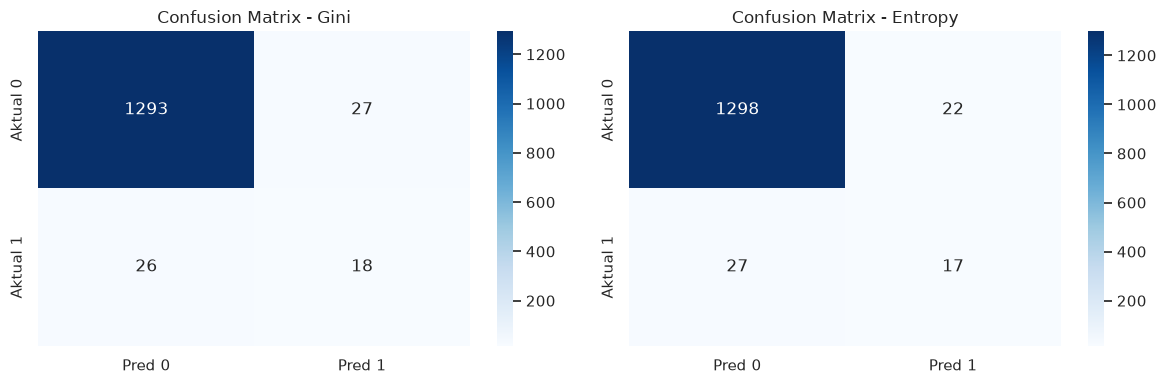

In [38]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
                             [y_pred_gini, y_pred_entropy],
                             ["Confusion Matrix - Gini", "Confusion Matrix - Entropy"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Aktual 0", "Aktual 1"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

Model terbaik (entropy, max_depth=5) -> accuracy=0.9663, F1 bangkrut=0.4390
                precision    recall  f1-score   support

Tidak Bangkrut       0.98      0.98      0.98      1320
      Bangkrut       0.47      0.41      0.44        44

      accuracy                           0.97      1364
     macro avg       0.73      0.70      0.71      1364
  weighted avg       0.96      0.97      0.97      1364



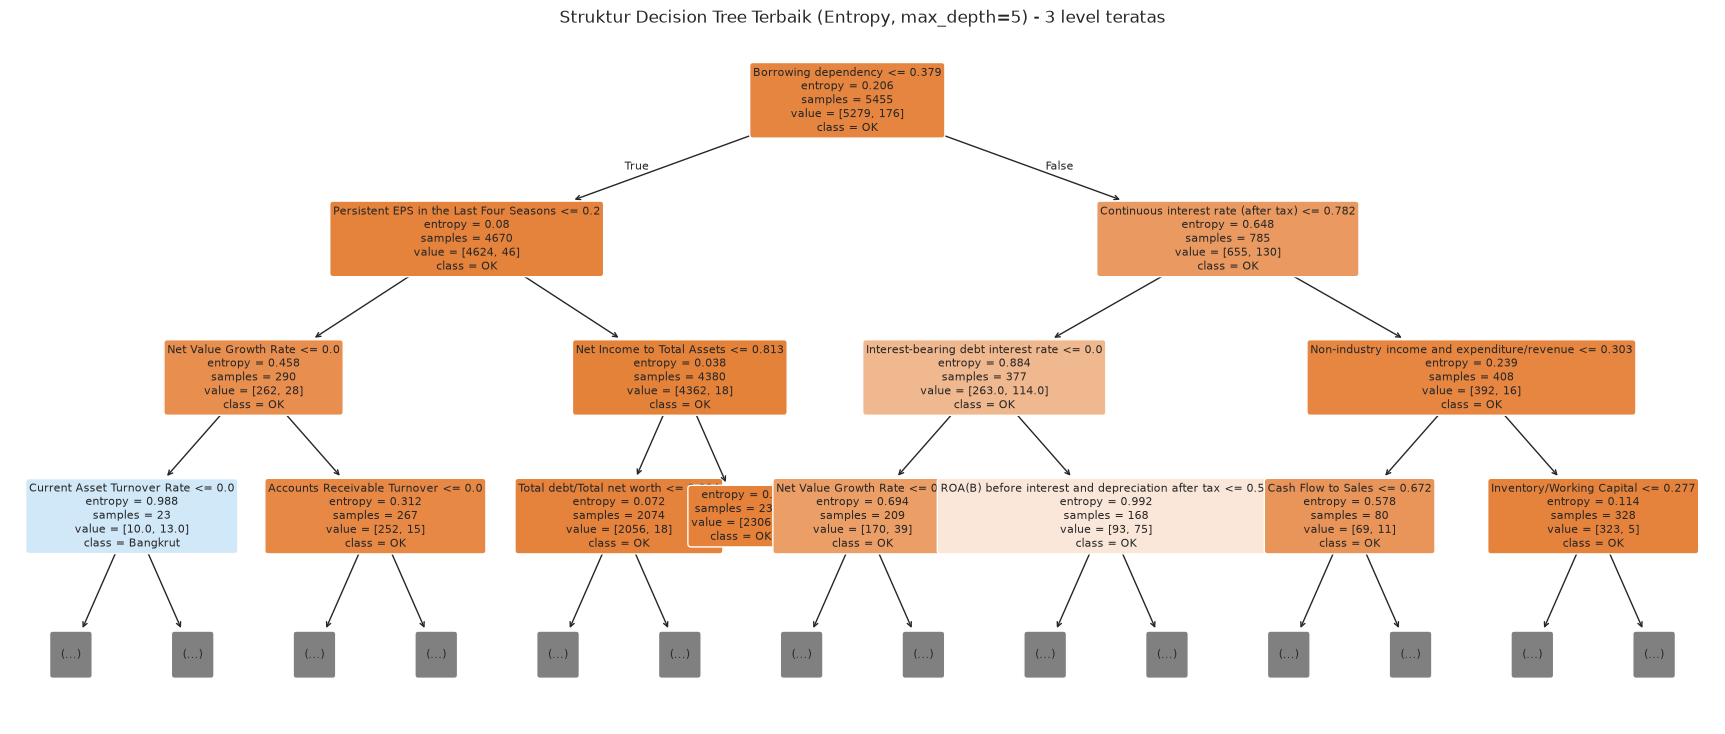

In [39]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
# Model terbaik = entropy dengan max_depth=5 (F1 kelas bangkrut tertinggi pada sweep di atas).
# Pohon asli berkedalaman 5, yang ditampilkan hanya 3 level teratas.
BEST_DEPTH = 5
dt_best = depth_models[BEST_DEPTH]
y_pred_best = dt_best.predict(X_test)
print(f"Model terbaik (entropy, max_depth={BEST_DEPTH}) -> "
      f"accuracy={accuracy_score(y_test, y_pred_best):.4f}, F1 bangkrut={f1_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=["Tidak Bangkrut", "Bangkrut"]))

plt.figure(figsize=(22, 9))
plot_tree(dt_best, filled=True, rounded=True, fontsize=8,
          feature_names=list(X.columns), class_names=["OK", "Bangkrut"],
          max_depth=3)
plt.title(f"Struktur Decision Tree Terbaik (Entropy, max_depth={BEST_DEPTH}) - 3 level teratas")
plt.show()

Borrowing dependency                                 0.3763
Continuous interest rate (after tax)                 0.1213
Persistent EPS in the Last Four Seasons              0.1114
Net Value Growth Rate                                0.0738
Interest-bearing debt interest rate                  0.0338
Net Income to Total Assets                           0.0304
ROA(B) before interest and depreciation after tax    0.0233
Non-industry income and expenditure/revenue          0.0216
Total debt/Total net worth                           0.0199
Operating Profit Growth Rate                         0.0196
dtype: float64

Jumlah fitur dengan importance > 0: 22


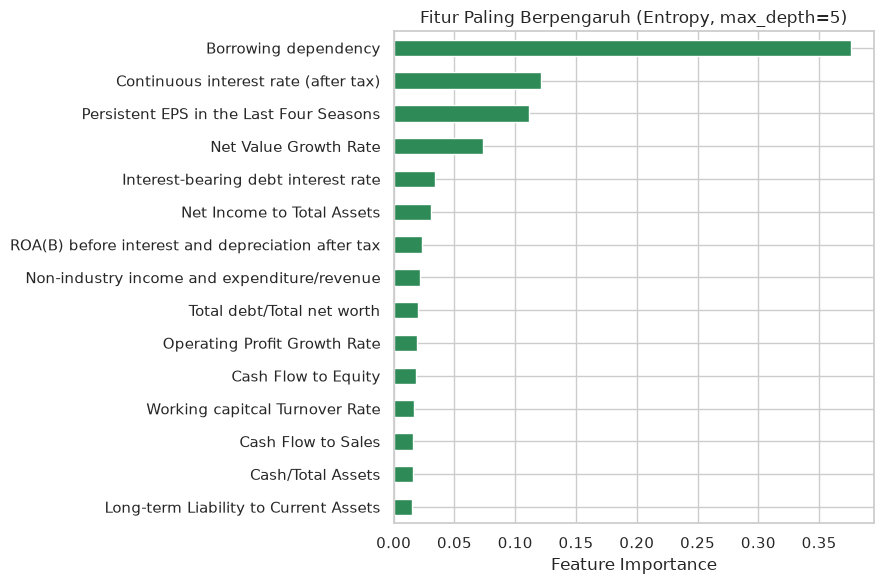

In [40]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(dt_best.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10).round(4))
print("\nJumlah fitur dengan importance > 0:", int((importances > 0).sum()))

plt.figure(figsize=(9, 6))
importances[importances > 0].head(15).sort_values().plot(kind="barh", color="seagreen")
plt.title(f"Fitur Paling Berpengaruh (Entropy, max_depth={BEST_DEPTH})")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

# 5. Analisis

### Hasil analisis eksperimen

**1. Gini vs Entropy.** Keduanya overfitting tanpa batas kedalaman (train acc 1.0). Di test set hasilnya praktis setara: acc 0.9611 vs 0.9641, F1 kelas bangkrut 0.4045 vs 0.4096. Selisihnya hanya ~4 dari 1364 sampel, jadi tidak signifikan. Wajar, karena Gini (`1 - Σp²`) dan Entropy (`-Σp log p`) berperilaku mirip dan memilih split yang serupa. Entropy dipakai selanjutnya sebagai *tie-break*. Kedua model hanya menangkap 17-18 dari 44 perusahaan bangkrut. Akibat imbalance 96.8% : 3.2%, accuracy ~0.96 menipu, dan metrik yang relevan adalah F1 kelas bangkrut (~0.40).

**2. Regularisasi max_depth (entropy).**

| max_depth | Daun | Train acc | Test acc | Recall bangkrut | F1 bangkrut |
|---|---|---|---|---|---|
| 1 | 2 | 0.9677 | 0.9677 | 0.0000 | 0.0000 |
| 2 | 4 | 0.9677 | 0.9677 | 0.0000 | 0.0000 |
| 3 | 8 | 0.9683 | **0.9699** | 0.1364 | 0.2264 |
| 5 | 25 | 0.9743 | 0.9663 | **0.4091** | **0.4390** |
| 10 | 82 | 0.9930 | 0.9633 | 0.3636 | 0.3902 |
| 15 | 97 | 0.9993 | 0.9626 | 0.3864 | 0.4000 |
| None | 99 | 1.0000 | 0.9641 | 0.3864 | 0.4096 |

Berdasarkan accuracy, depth 3 tampak terbaik, padahal depth 1-2 tidak pernah memprediksi bangkrut (0.9677 = baseline kelas mayoritas) dan depth 3 hanya menangkap 6 dari 44. Depth ≤ 3 underfitting. Berdasarkan F1, **max_depth=5** optimal (0.4390, dengan 25 daun), lebih baik dari pohon tanpa batas (0.4096, dengan 99 daun). Di atas depth 5 model overfitting: train acc naik ke 1.0, sedangkan test acc turun dan F1 tidak membaik. *Catatan:* hyperparameter dipilih berdasarkan test set, sehingga skornya sedikit optimistis. Idealnya pemilihan dilakukan dengan cross-validation pada train set.

**3. Fitur paling berpengaruh.** Pada model terbaik (entropy, depth 5), fitur teratas adalah Borrowing dependency (0.376, sekaligus root split), Continuous interest rate after tax (0.121), Persistent EPS (0.111), dan Net Value Growth Rate (0.074). Hanya 22 dari 95 fitur yang terpakai. Fitur dengan korelasi tertinggi pada EDA (Net Income to Total Assets, kelompok ROA) justru ber-importance kecil, karena informasinya redundan dengan Persistent EPS yang sudah dipakai. Secara finansial ini masuk akal: beban utang tinggi dan profitabilitas rendah adalah sinyal utama kebangkrutan.

# 6. Kesimpulan

### Kesimpulan
1. Model Decision Tree mencapai akurasi test ~0.96-0.97, tetapi karena imbalance kelas yang ekstrem, angka tersebut didominasi kelas mayoritas (baseline "selalu tidak bangkrut" saja sudah 0.9677). Kemampuan mendeteksi kebangkrutan yang sesungguhnya hanya moderat (F1 kelas bangkrut ~0.41-0.44, recall ~0.39-0.41).
2. Gini dan Entropy memberikan hasil yang praktis setara pada data ini (test acc 0.9611 vs 0.9641, F1 0.4045 vs 0.4096); selisihnya hanya ~4 sampel sehingga tidak signifikan, karena kedua fungsi impurity memilih split yang serupa.
3. Regularisasi max_depth terbukti mengendalikan overfitting, tetapi pemilihan depth harus memakai metrik yang tepat. Berdasarkan accuracy, depth 3 tampak terbaik, padahal model tersebut hanya menangkap 6 dari 44 perusahaan bangkrut. Berdasarkan F1 kelas bangkrut, **max_depth=5** adalah yang terbaik (F1 0.4390 vs 0.4096 untuk pohon tanpa batas) dengan pohon yang jauh lebih sederhana (25 vs 99 daun). Di atas depth 5 model overfitting (train → 1.0, test tidak membaik).
4. Fitur kunci prediksi adalah Borrowing dependency (root split), Continuous interest rate after tax, dan Persistent EPS — selaras dengan intuisi finansial bahwa beban utang dan profitabilitas menentukan kebangkrutan.